# Final Report Figure Generation Workspace
This is a place where we can use Matplot to generate any necessary figures for the the poster or final report if needed.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"] = "serif"
rcParams["font.serif"] = ["Times New Roman", "Times", "Liberation Serif", "DejaVu Serif"]
rcParams["mathtext.fontset"] = "stix"
rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 1.2, "lines.linewidth": 2.4, "lines.markersize": 9,
    "figure.dpi": 120, "savefig.bbox": "tight",
})

TEAL  = "#00693E" # Changed to Dartmouth Green but still labeled teal because used below
CORAL = "#D85A30"
GRAY  = "#5F5E5A"
LIGHT = "#B4B2A9"

mac_bits = np.array([3, 4, 5, 6, 8, 10, 12, 16])
prd      = np.array([82.9, 74.6, 39.3, 22.5, 20.4, 20.1, 20.1, 20.1])   # REAL
KNEE_BITS = 8

# FAKE resource numbers (illustrative) — replace with HDL-A's real synthesis data
IS_MOCK     = True
dsp         = np.array([6, 8, 11, 16, 26, 40, 58, 96])
lut         = np.array([420, 540, 690, 910, 1340, 1980, 2760, 4300])
bram        = np.array([2, 2, 2, 3, 4, 6, 8, 12])
latency_cyc = np.array([1032, 1032, 1032, 1036, 1040, 1048, 1060, 1088])

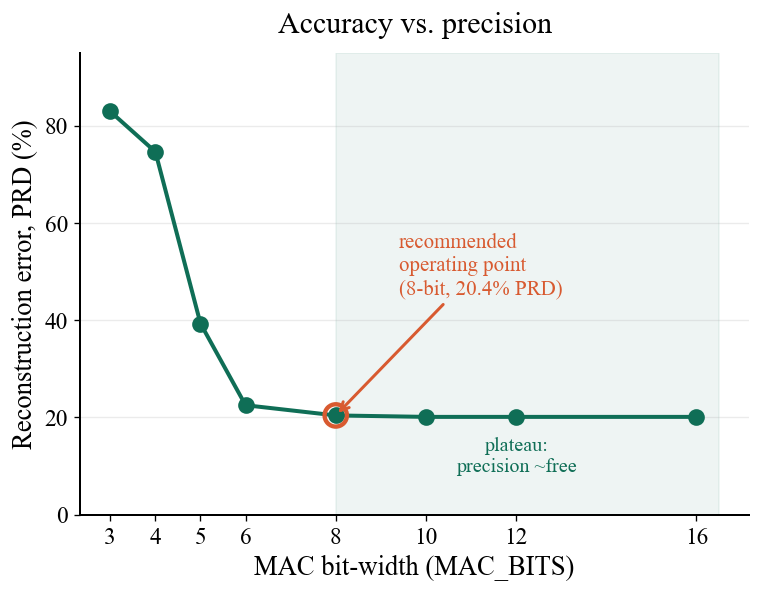

In [9]:
fig1, ax1 = plt.subplots(figsize=(7.2, 5.0))
ax1.plot(mac_bits, prd, "-o", color=TEAL, zorder=3)

knee_prd = prd[mac_bits == KNEE_BITS][0]
ax1.scatter([KNEE_BITS], [knee_prd], s=180, facecolor="none",
            edgecolor=CORAL, linewidth=2.6, zorder=4)
ax1.annotate(f"recommended\noperating point\n({KNEE_BITS}-bit, {knee_prd:.1f}% PRD)",
             xy=(KNEE_BITS, knee_prd), xytext=(KNEE_BITS+1.4, knee_prd+24),
             fontsize=12.5, color=CORAL, ha="left", va="bottom",
             arrowprops=dict(arrowstyle="->", color=CORAL, lw=1.8))
ax1.axvspan(KNEE_BITS, mac_bits.max()+0.5, color=TEAL, alpha=0.07, zorder=0)
ax1.text((KNEE_BITS+mac_bits.max())/2, 8, "plateau:\nprecision ~free",
         ha="center", va="bottom", fontsize=12, color=TEAL)

ax1.set_xlabel("MAC bit-width (MAC_BITS)", fontsize=16)
ax1.set_ylabel("Reconstruction error, PRD (%)", fontsize=16)
ax1.set_title("Accuracy vs. precision", fontsize=18, pad=12)
ax1.set_xticks(mac_bits); ax1.tick_params(labelsize=14)
ax1.set_ylim(0, 95); ax1.grid(True, axis="y", alpha=0.25)

fig1.savefig("accuracy_axis.png", dpi=300)
fig1.savefig("accuracy_axis.pdf")
plt.show()

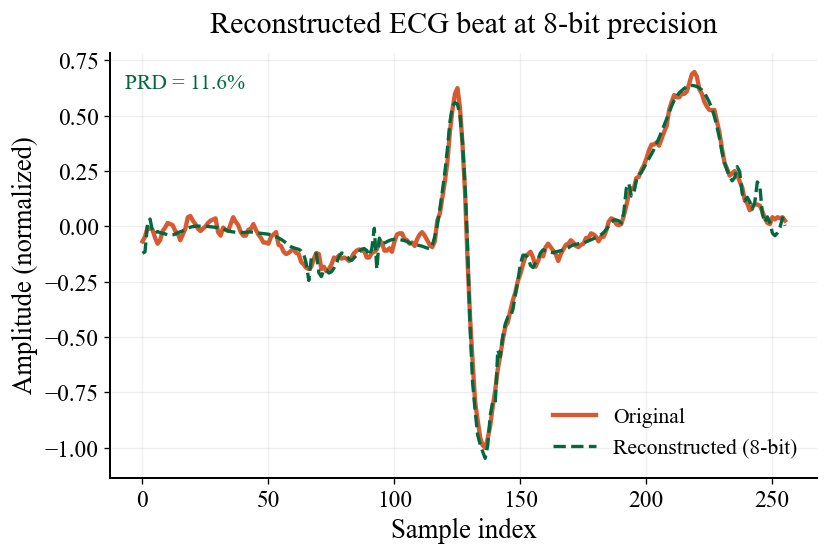

In [30]:
# --- DATA: replace these two lines with your real exports ---
try:
    orig  = np.load("beat_original.npy")
    recon = np.load("beat_recon.npy")
    IS_SYNTHETIC = False
except FileNotFoundError:
    # synthetic ECG-like placeholder so you can see the layout
    t = np.linspace(0, 1, 256)
    def beat(t):
        p = 0.1*np.exp(-((t-0.2)/0.025)**2)
        q = -0.15*np.exp(-((t-0.38)/0.008)**2)
        r = 1.0*np.exp(-((t-0.4)/0.009)**2)
        s = -0.25*np.exp(-((t-0.42)/0.009)**2)
        tw = 0.2*np.exp(-((t-0.62)/0.04)**2)
        return p+q+r+s+tw
    orig = beat(t)
    rng = np.random.default_rng(0)
    recon = orig + 0.04*rng.standard_normal(256) + 0.03*np.sin(2*np.pi*6*t)
    IS_SYNTHETIC = True

prd_window = 100 * np.linalg.norm(orig - recon) / np.linalg.norm(orig)

fig2, ax2 = plt.subplots(figsize=(7.6, 4.6))
ax2.plot(orig,  color=CORAL,  linewidth=2.6, label="Original", zorder=2)
ax2.plot(recon, color=TEAL, linewidth=2.0, label=f"Reconstructed ({KNEE_BITS}-bit)",
         linestyle="--", zorder=3)
ax2.set_xlabel("Sample index", fontsize=16)
ax2.set_ylabel("Amplitude (normalized)", fontsize=16)
title = "Reconstructed ECG beat at 8-bit precision"
if IS_SYNTHETIC:
    title += "   [ILLUSTRATIVE]"
ax2.set_title(title, fontsize=18, pad=12)
ax2.tick_params(labelsize=14)
ax2.legend(fontsize=13, frameon=False, loc="lower right")
ax2.text(0.02, 0.95, f"PRD = {prd_window:.1f}%", transform=ax2.transAxes,
         fontsize=13, color=TEAL, va="top")
ax2.grid(True, alpha=0.2)

fig2.savefig("recon_beat.png", dpi=300)
fig2.savefig("recon_beat.pdf")
plt.show()

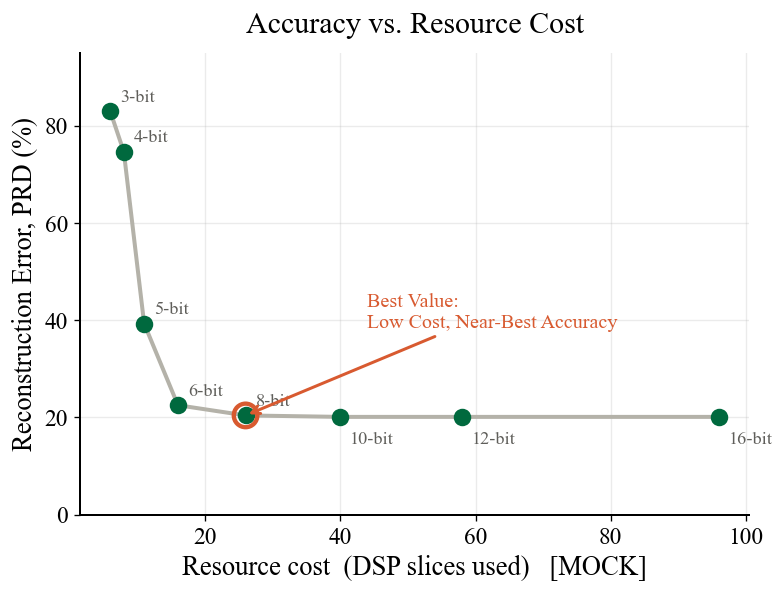

In [31]:
fig3, ax3 = plt.subplots(figsize=(7.2, 5.0))
cost = dsp
order = np.argsort(cost)
ax3.plot(cost[order], prd[order], "-", color=LIGHT, zorder=2)
ax3.scatter(cost, prd, s=90, color=TEAL, zorder=3)
for b, c, p in zip(mac_bits, cost, prd):
    off = (6, 6) if b not in (10, 12, 16) else (6, -16)
    ax3.annotate(f"{b}-bit", (c, p), xytext=off,
                 textcoords="offset points", fontsize=11, color=GRAY)
cknee = cost[mac_bits == KNEE_BITS][0]; pknee = prd[mac_bits == KNEE_BITS][0]
ax3.scatter([cknee], [pknee], s=200, facecolor="none",
            edgecolor=CORAL, linewidth=2.6, zorder=4)
ax3.annotate("Best Value: \nLow Cost, Near-Best Accuracy", xy=(cknee, pknee),
             xytext=(cknee+18, pknee+18), fontsize=12, color=CORAL,
             arrowprops=dict(arrowstyle="->", color=CORAL, lw=1.8))
xlabel = "Resource cost  (DSP slices used)"
if IS_MOCK: xlabel += "   [MOCK]"
ax3.set_xlabel(xlabel, fontsize=16)
ax3.set_ylabel("Reconstruction Error, PRD (%)", fontsize=16)
ax3.set_title("Accuracy vs. Resource Cost", fontsize=18, pad=12)
ax3.tick_params(labelsize=14); ax3.set_ylim(0, 95); ax3.grid(True, alpha=0.25)

fig3.savefig("pareto_front.png", dpi=300)
fig3.savefig("pareto_front.pdf")
plt.show()

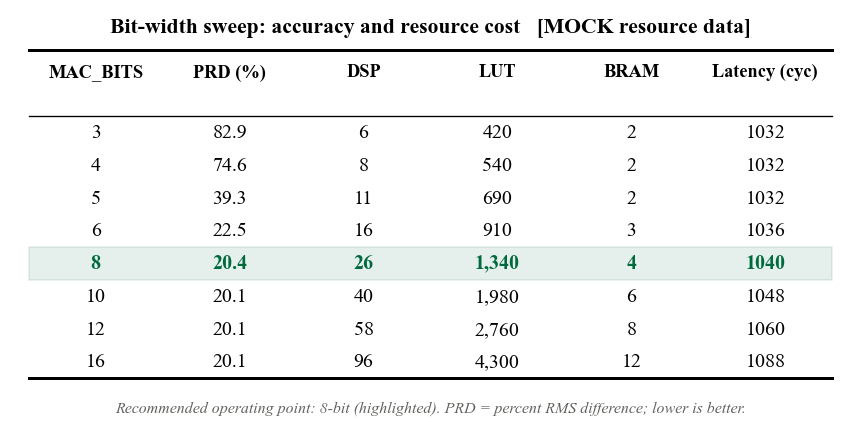

In [21]:
def render_table():
    col_headers = ["MAC_BITS", "PRD (%)", "DSP", "LUT", "BRAM", "Latency (cyc)"]
    # src_tags    = ["", "[HDL-B]", "[HDL-A]", "[HDL-A]", "[HDL-A]", "[HDL-A]"]
    rows = [[str(b), f"{prd[i]:.1f}", str(dsp[i]), f"{lut[i]:,}",
             str(bram[i]), str(latency_cyc[i])] for i, b in enumerate(mac_bits)]
    n_rows = len(rows) + 2
    n_cols = len(col_headers)

    fig, ax = plt.subplots(figsize=(9.0, 0.42 * n_rows + 0.3))
    ax.axis("off")
    col_x = np.linspace(0.10, 0.90, n_cols)
    row_h = 1.0 / (n_rows + 0.5)
    y_top = 1.0

    ax.axhline(y_top,                color="black", lw=1.8, xmin=0.02, xmax=0.98)
    ax.axhline(y_top - 2*row_h,      color="black", lw=0.8, xmin=0.02, xmax=0.98)
    ax.axhline(y_top - n_rows*row_h, color="black", lw=1.8, xmin=0.02, xmax=0.98)

    for cx, h, tag in zip(col_x, col_headers, src_tags):
        ax.text(cx, y_top - 0.65*row_h, h, ha="center", va="center",
                fontsize=11, fontweight="bold")
        

    for r, row in enumerate(rows):
        yr = y_top - (2 + r + 0.5) * row_h
        knee = (int(row[0]) == KNEE_BITS)
        if knee:
            ax.axhspan(yr - 0.5*row_h, yr + 0.5*row_h,
                       xmin=0.02, xmax=0.98, color=TEAL, alpha=0.10, zorder=0)
        for cx, cell in zip(col_x, row):
            ax.text(cx, yr, cell, ha="center", va="center", fontsize=12,
                    fontweight=("bold" if knee else "normal"),
                    color=(TEAL if knee else "black"))

    title = "Bit-width sweep: accuracy and resource cost"
    if IS_MOCK: title += "   [MOCK resource data]"
    ax.text(0.5, y_top + 0.4*row_h, title, ha="center", va="bottom",
            fontsize=13, fontweight="bold")
    ax.text(0.5, y_top - (n_rows + 0.7)*row_h,
            "Recommended operating point: 8-bit (highlighted). "
            "PRD = percent RMS difference; lower is better.",
            ha="center", va="top", fontsize=9.5, color=GRAY, style="italic")
    ax.set_xlim(0, 1); ax.set_ylim(y_top - (n_rows + 1.5)*row_h, y_top + 1.2*row_h)
    fig.savefig("data_table.png", dpi=300, bbox_inches="tight")
    plt.show()

render_table()